In [ ]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving LoanEligibilityPrediction.csv to LoanEligibilityPrediction.csv


In [ ]:
# Replace 'your_file.csv' with your actual file name
df = pd.read_csv('LoanEligibilityPrediction.csv')
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [ ]:
print(df.dtypes)

Customer_ID             int64
Gender                 object
Married                object
Dependents              int64
Education              object
Self_Employed          object
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area          object
Loan_Status            object
dtype: object


In [ ]:
print(df.shape)

(614, 13)


In [ ]:
print(df.info)

<bound method DataFrame.info of      Customer_ID  Gender Married  Dependents     Education Self_Employed  \
0            569  Female      No           0      Graduate            No   
1             15    Male     Yes           2      Graduate            No   
2             95    Male      No           0  Not Graduate            No   
3            134    Male     Yes           0      Graduate           Yes   
4            556    Male     Yes           1      Graduate            No   
..           ...     ...     ...         ...           ...           ...   
609          480    Male     Yes           2      Graduate            No   
610          525    Male      No           0      Graduate            No   
611          551    Male     Yes           2      Graduate           Yes   
612          552    Male     Yes           1  Not Graduate            No   
613          606    Male     Yes           0  Not Graduate            No   

     Applicant_Income  Coapplicant_Income  Loan_Amount 

In [ ]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [ ]:
df.tail()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y
613,606,Male,Yes,0,Not Graduate,No,2400,3800.0,25,180,1,Urban,N


Gender(Male,Female) ,Married(Yes,No),Education(Graduate,Not Graduate),Self_Employed(NO,Yes),Loan_status(N,Y)

In [ ]:
#missing values
print(df.isnull().sum())

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
df[df.isnull().any(axis=1)]

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


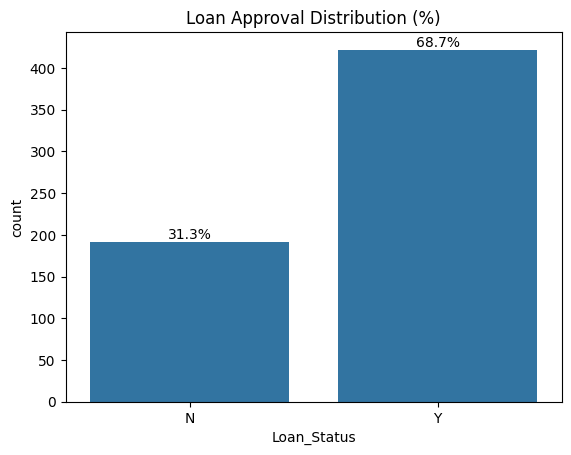

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot
ax = sns.countplot(x='Loan_Status', data=df)

# total samples
total = len(df)

# add percentage labels
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title("Loan Approval Distribution (%)")
plt.show()

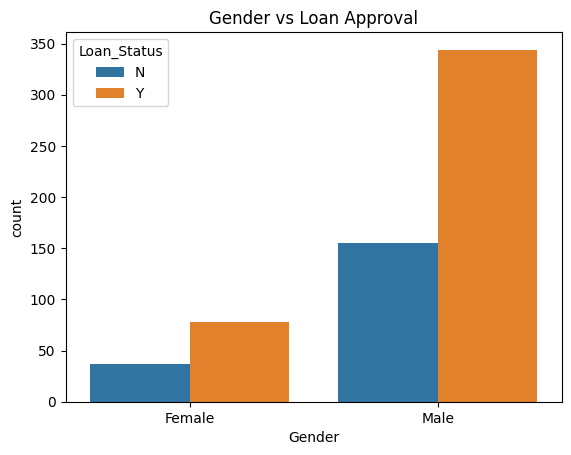

In [ ]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Gender vs Loan Approval")
plt.show()

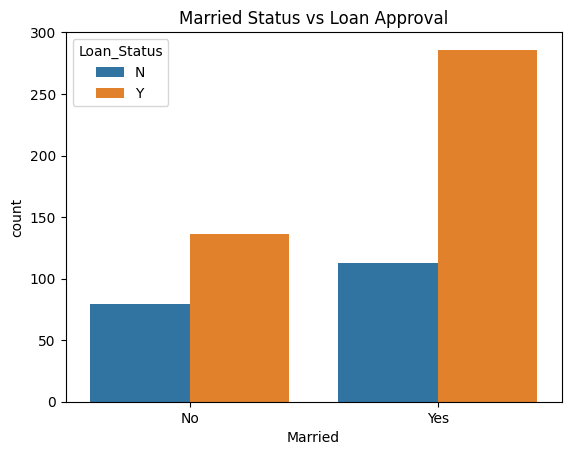

In [ ]:
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.title("Married Status vs Loan Approval")
plt.show()

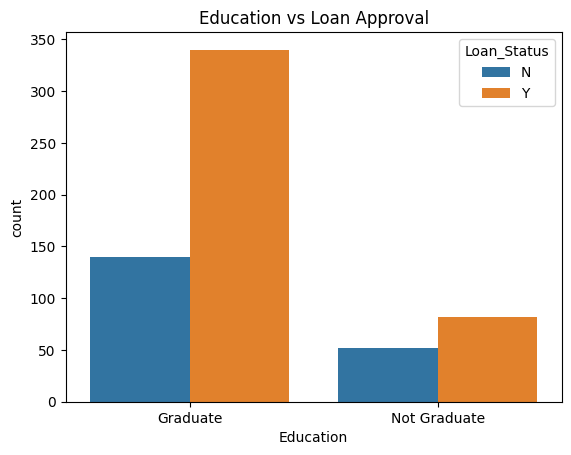

In [ ]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Approval")
plt.show()

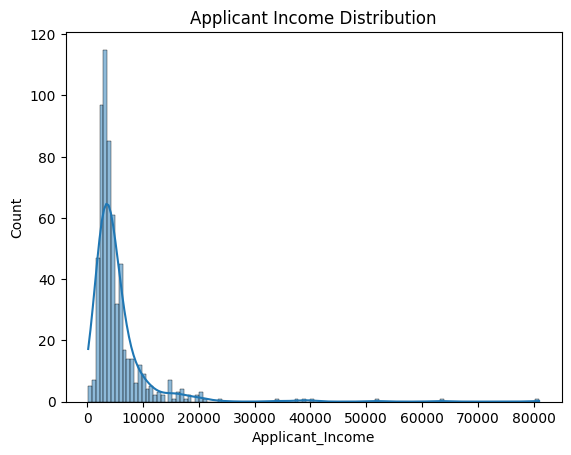

In [ ]:
sns.histplot(df['Applicant_Income'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

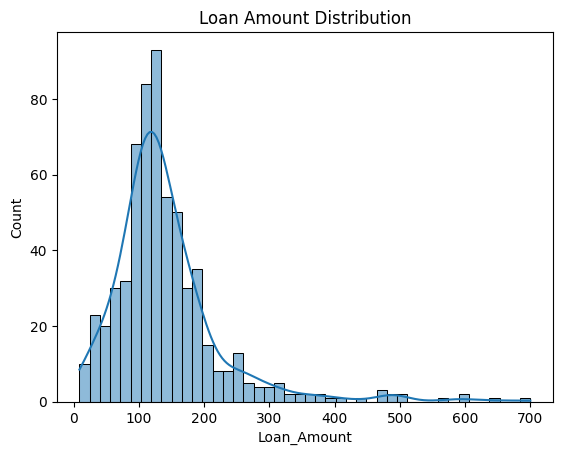

In [ ]:
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

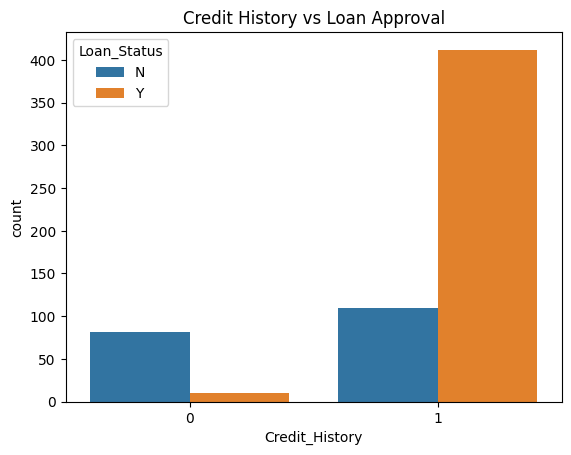

In [ ]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

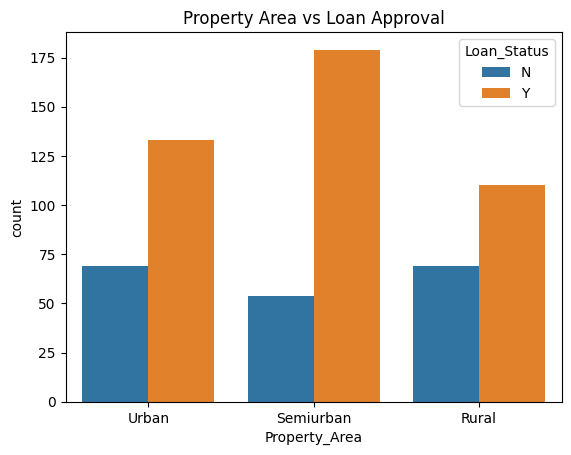

In [ ]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

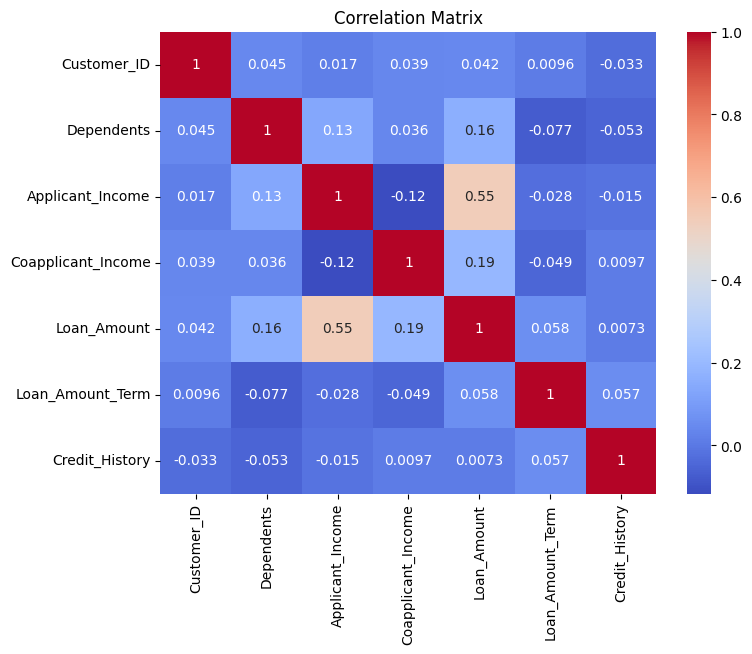

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# ---------------------------
# 3. Encoding binary categorical variables
# ---------------------------

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
# ---------------------------
# 4. One-hot encoding (multi-class feature)
# ---------------------------
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)



In [ ]:
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,569,0,0,0,1,0,2378,0.0,9,360,1,0,False,True
1,15,1,1,2,1,0,1299,1086.0,17,120,1,1,False,True
2,95,1,0,0,0,0,3620,0.0,25,120,1,1,True,False
3,134,1,1,0,1,1,3459,0.0,25,120,1,1,True,False
4,556,1,1,1,1,0,5468,1032.0,26,360,1,1,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,1,1,2,1,0,2947,1603.0,10,360,1,0,False,True
610,525,1,0,0,1,0,4680,2087.0,15,360,1,0,True,False
611,551,1,1,2,1,1,6633,0.0,25,360,0,0,False,False
612,552,1,1,1,0,0,2492,2375.0,30,360,1,1,False,False


In [ ]:
df['Property_Area_Semiurban'] = df['Property_Area_Semiurban'].astype(int)
df['Property_Area_Urban'] = df['Property_Area_Urban'].astype(int)

In [ ]:
df = df.drop('Customer_ID', axis=1)

In [ ]:
df

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0,1,0,2378,0.0,9,360,1,0,0,1
1,1,1,2,1,0,1299,1086.0,17,120,1,1,0,1
2,1,0,0,0,0,3620,0.0,25,120,1,1,1,0
3,1,1,0,1,1,3459,0.0,25,120,1,1,1,0
4,1,1,1,1,0,5468,1032.0,26,360,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,1,2,1,0,2947,1603.0,10,360,1,0,0,1
610,1,0,0,1,0,4680,2087.0,15,360,1,0,1,0
611,1,1,2,1,1,6633,0.0,25,360,0,0,0,0
612,1,1,1,0,0,2492,2375.0,30,360,1,1,0,0


In [ ]:
import pandas as pd

# Define target variable (Y)
y = df['Loan_Status']

# Define feature variables (X)
X = df.drop('Loan_Status', axis=1)

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (614, 12)
Y shape: (614,)


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Normalize (VERY IMPORTANT STEP)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [45]:
# Logistic Regression model with class weights
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'   # 👈 this is the key fix
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.7622377622377622
Test Accuracy: 0.7351351351351352


In [47]:
from sklearn.metrics import classification_report

# Train metrics
y_train_pred = model.predict(X_train)
print("TRAIN CLASSIFICATION REPORT:\n")
print(classification_report(y_train, y_train_pred))

# Test metrics
y_test_pred = model.predict(X_test)
print("\nTEST CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_test_pred))

TRAIN CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.62      0.59      0.60       131
           1       0.82      0.84      0.83       298

    accuracy                           0.76       429
   macro avg       0.72      0.71      0.72       429
weighted avg       0.76      0.76      0.76       429


TEST CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.60      0.57      0.59        61
           1       0.80      0.81      0.80       124

    accuracy                           0.74       185
   macro avg       0.70      0.69      0.70       185
weighted avg       0.73      0.74      0.73       185



In [48]:
from sklearn.metrics import roc_auc_score

# Probabilities (important for ROC-AUC)
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# ROC-AUC scores
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC:", test_auc)

Train ROC-AUC: 0.7845688816025411
Test ROC-AUC: 0.7470914859862507


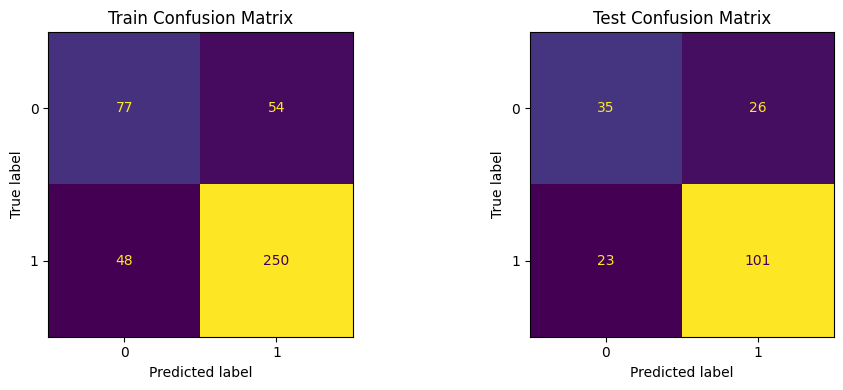

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Confusion Matrix (Train)
cm_train = confusion_matrix(y_train, y_train_pred)

# Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_train).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

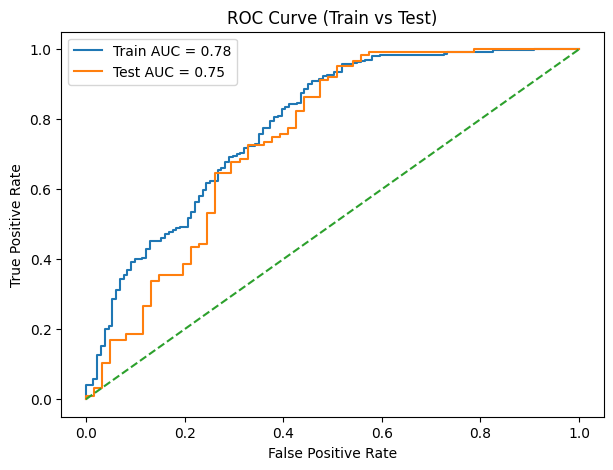

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# ROC Curve values
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# AUC scores
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.2f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.2f}")

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train vs Test)")
plt.legend()
plt.show()

In [51]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

print(results.head(10))

   Actual  Predicted
0       1          0
1       1          0
2       1          1
3       0          1
4       1          1
5       1          1
6       1          1
7       1          1
8       0          1
9       0          1


In [52]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Probability": y_test_prob
})

print(results.head(10))

   Actual  Predicted  Probability
0       1          0     0.468230
1       1          0     0.454278
2       1          1     0.774802
3       0          1     0.701478
4       1          1     0.707615
5       1          1     0.597701
6       1          1     0.569563
7       1          1     0.766364
8       0          1     0.536127
9       0          1     0.762816


In [53]:
import pandas as pd

# Actual counts
actual_counts = y_test.value_counts()

# Predicted counts
pred_counts = pd.Series(y_test_pred).value_counts()

print("Actual Class Distribution:\n", actual_counts)
print("\nPredicted Class Distribution:\n", pred_counts)

Actual Class Distribution:
 Loan_Status
1    124
0     61
Name: count, dtype: int64

Predicted Class Distribution:
 1    127
0     58
Name: count, dtype: int64


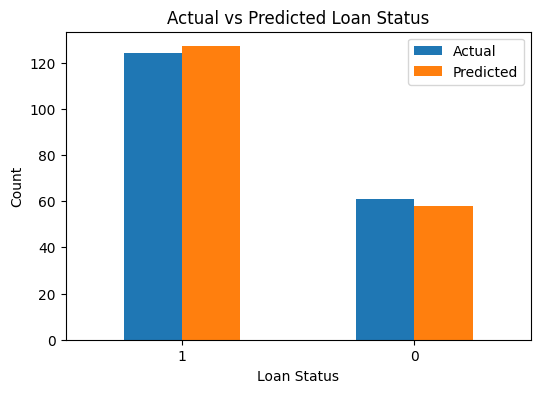

In [54]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": pred_counts
}).fillna(0)

comparison.plot(kind="bar", figsize=(6,4))

plt.title("Actual vs Predicted Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()